### Training error (bias) and test error (variance) behave differently depending on model complexity.

Overfitting → low bias, high variance (model fits training data too closely).

Underfitting → high bias, low variance (model too simple).

The ideal generalized model achieves both low bias and low variance — the sweet spot of generalization.

## Import libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,auc,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,StackingClassifier,VotingClassifier
from matplotlib import pyplot as plt
from pickle import dump

## Business Understanding, Data Collection, DataCleaning

In [2]:
claimant_details=pd.read_csv("claimants.csv")
claimant_details             

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [3]:
claimant_details.dropna(inplace=True)

In [4]:
claimant_details

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## Data Preparation

In [5]:
X=claimant_details.iloc[:,2:]
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [6]:
y = claimant_details.iloc[:,1]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## Data spliting / Model evaluation techniques

#### Train Split Test

In [7]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.20,shuffle=True,random_state=45)

#### K-Fold cross validation

In [9]:
from sklearn.model_selection import KFold,LeaveOneOut,cross_val_score

In [14]:
k_fold=KFold(shuffle=True,random_state=34)
cv=cross_val_score(estimator=logistic_model,X=X,y=y,cv=k_fold)
print(cv)
print(cv.mean())
print(cv.std())

[0.68181818 0.7260274  0.74429224 0.69863014 0.6803653 ]
0.7062266500622665
0.025152926102290172


#### Leaveoneout

In [15]:
loocv=LeaveOneOut()
cv=cross_val_score(estimator=logistic_model,X=X,y=y,cv=loocv)
print(cv)
print(cv.mean())
print(cv.std())

[1. 1. 1. ... 1. 1. 1.]
0.7025547445255474
0.4571340891578643


## Model building, Training, Testing and Evaluation

### Logistic Regression

In [10]:
logistic_model = LogisticRegression()

In [9]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred_train=logistic_model.predict(X_train)

In [11]:
y_pred_test=logistic_model.predict(X_test)

### Evaluation Metrics

In [12]:
print("Train: ",confusion_matrix(y_train,y_pred_train))
print("Test: ",confusion_matrix(y_test,y_pred_test))

Train:  [[310 159]
 [ 96 311]]
Test:  [[73 36]
 [30 81]]


In [13]:
print(classification_report(y_train,y_pred_train))
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.76      0.66      0.71       469
           1       0.66      0.76      0.71       407

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.72      0.71      0.71       876

              precision    recall  f1-score   support

           0       0.71      0.67      0.69       109
           1       0.69      0.73      0.71       111

    accuracy                           0.70       220
   macro avg       0.70      0.70      0.70       220
weighted avg       0.70      0.70      0.70       220



0.7125542871811529


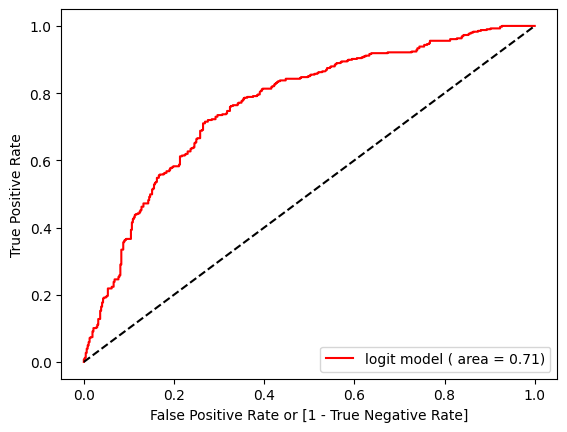

In [14]:
fpr, tpr, thresholds = roc_curve(y_train, logistic_model.predict_proba(X_train)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_train,y_pred_train)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


0.6997272501859658


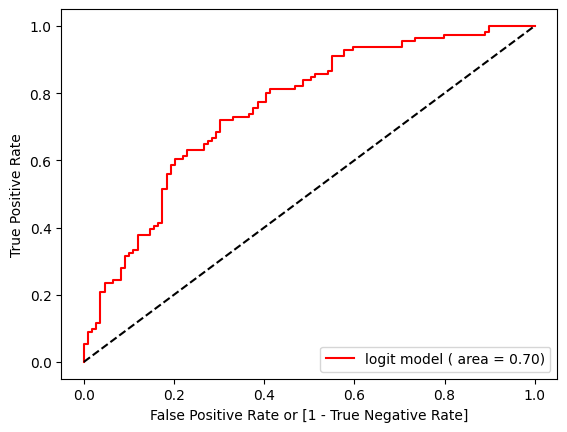

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_test,y_pred_test)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


### Decision Tree

In [16]:
dt_model = DecisionTreeClassifier(max_depth=5)

In [48]:
grid_search = GridSearchCV(estimator=dt_model,param_grid={"criterion":["gini", "entropy"],
                                           "max_depth":[3,4,5,6,7,8,9,10]})
grid_search.fit(X_train,y_train)

print(grid_search.best_params_)

grid_search.best_score_

{'criterion': 'gini', 'max_depth': 3}


np.float64(0.7362792207792207)

In [17]:
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
y_pred_train_dt=dt_model.predict(X_train)

In [19]:
y_pred_test_dt = dt_model.predict(X_test)

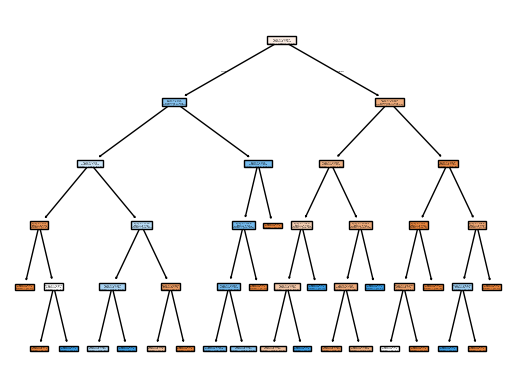

In [58]:
plot_tree(dt_model,filled=True)
plt.show()

### Evaluation Metrics

In [20]:
print(confusion_matrix(y_train,y_pred_train_dt))
print(confusion_matrix(y_test,y_pred_test_dt))

[[372  97]
 [112 295]]
[[86 23]
 [38 73]]


In [33]:
print(classification_report(y_train,y_pred_train_dt))
print(classification_report(y_test,y_pred_test_dt))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       469
           1       0.75      0.72      0.74       407

    accuracy                           0.76       876
   macro avg       0.76      0.76      0.76       876
weighted avg       0.76      0.76      0.76       876

              precision    recall  f1-score   support

           0       0.69      0.79      0.74       109
           1       0.76      0.66      0.71       111

    accuracy                           0.72       220
   macro avg       0.73      0.72      0.72       220
weighted avg       0.73      0.72      0.72       220



0.7589963485485873


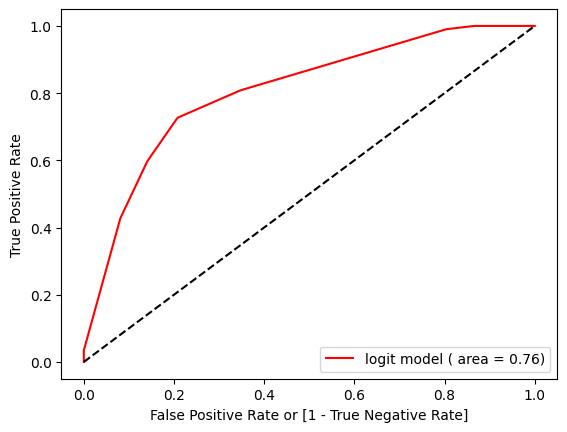

In [22]:
fpr, tpr, thresholds = roc_curve(y_train, dt_model.predict_proba(X_train)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_train,y_pred_train_dt)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


0.7233242416728655


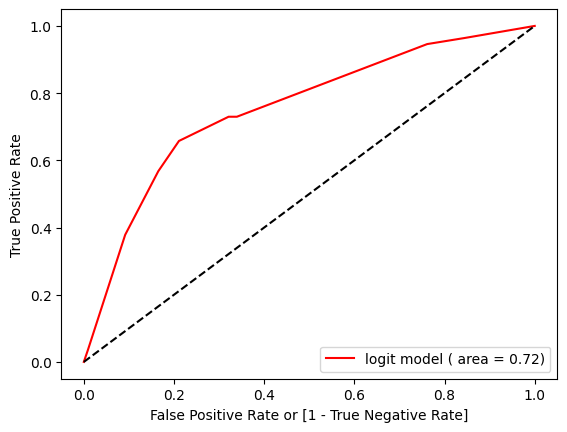

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_test,y_pred_test_dt)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


## Ensemble Techniques to overcome model overfitting (low bias and high variance)\
- Bagging --> randomforest
  - bagging/bootstrap
  - it increases stability
  - involves n number of decision tree for a single dataset doing the math parallely and derives the output
  - sampling with replacement
  - subfeature classification

- Boosting/adaboost --> gradient boosting
    - sequential classification
    - sampling based on error
    - it increses accuracy

- stacking --> works with multiple algorithms
    - works parallely with multiple algorithms
    - gets the predicted output based on voting classification
    - we dont use it most of the times
    

## Random Forest

In [28]:
randforest=RandomForestClassifier(max_depth=5,n_estimators=100)

In [27]:
grid_search = GridSearchCV(estimator=randforest,param_grid={"criterion":["gini", "entropy"],"max_depth":[3,4,5,6,7,8,9,10],"n_estimators":[50,100,120,150,75]
                                                         })
grid_search.fit(X_train,y_train)

print(grid_search.best_params_)

grid_search.best_score_

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}


np.float64(0.738564935064935)

In [29]:
randforest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_train_rand = randforest.predict(X_train)

In [31]:
y_pred_test_rand =randforest.predict(X_test)

### Evaluation Metrics

In [32]:
print(confusion_matrix(y_train,y_pred_train_rand))
print(confusion_matrix(y_test,y_pred_test_rand))

[[367 102]
 [118 289]]
[[87 22]
 [39 72]]


In [34]:
print(classification_report(y_train,y_pred_train_rand))
print(classification_report(y_test,y_pred_test_rand))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77       469
           1       0.74      0.71      0.72       407

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       109
           1       0.77      0.65      0.70       111

    accuracy                           0.72       220
   macro avg       0.73      0.72      0.72       220
weighted avg       0.73      0.72      0.72       220



0.7462948507724626


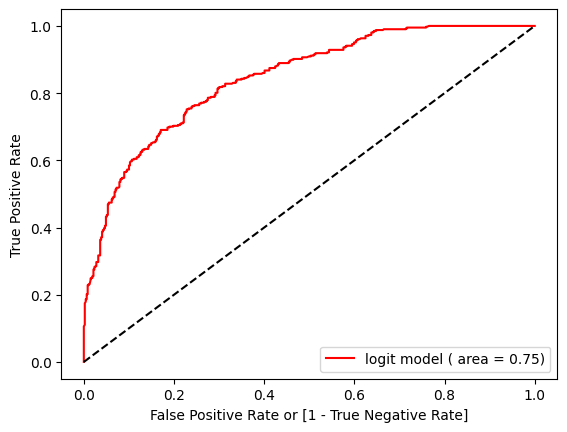

In [35]:
fpr, tpr, thresholds = roc_curve(y_train, randforest.predict_proba(X_train)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_train,y_pred_train_rand)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


0.7234068931316637


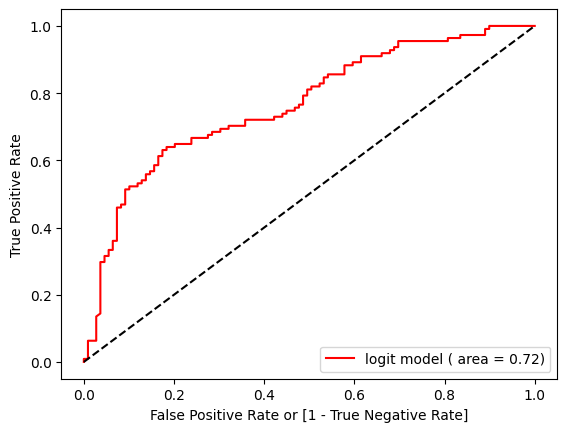

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, randforest.predict_proba(X_test)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_test,y_pred_test_rand)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


### AdaBoost

In [38]:
ada_boost=AdaBoostClassifier()
ada_boost.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [39]:
y_pred_train_adaboost = ada_boost.predict(X_train)

In [40]:
y_pred_test_adaboost = ada_boost.predict(X_test)

### Evaluation Metrics 

In [41]:
print(confusion_matrix(y_train,y_pred_train_adaboost))
print(confusion_matrix(y_test,y_pred_test_adaboost))

[[357 112]
 [121 286]]
[[82 27]
 [40 71]]


In [42]:
print(classification_report(y_train,y_pred_train_adaboost))
print(classification_report(y_test,y_pred_test_adaboost))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75       469
           1       0.72      0.70      0.71       407

    accuracy                           0.73       876
   macro avg       0.73      0.73      0.73       876
weighted avg       0.73      0.73      0.73       876

              precision    recall  f1-score   support

           0       0.67      0.75      0.71       109
           1       0.72      0.64      0.68       111

    accuracy                           0.70       220
   macro avg       0.70      0.70      0.69       220
weighted avg       0.70      0.70      0.69       220



0.7319483662767244


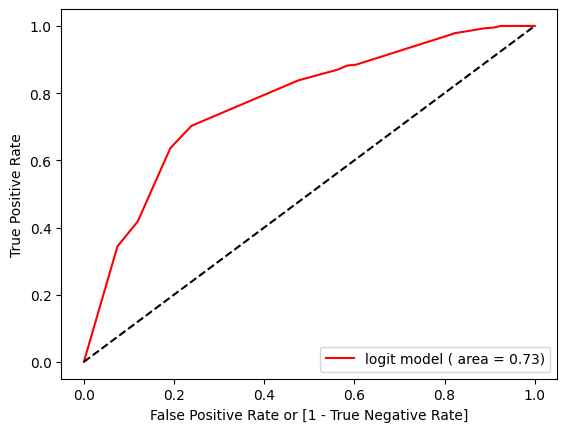

In [43]:
fpr, tpr, thresholds = roc_curve(y_train, ada_boost.predict_proba(X_train)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_train,y_pred_train_adaboost)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


0.6959666088106455


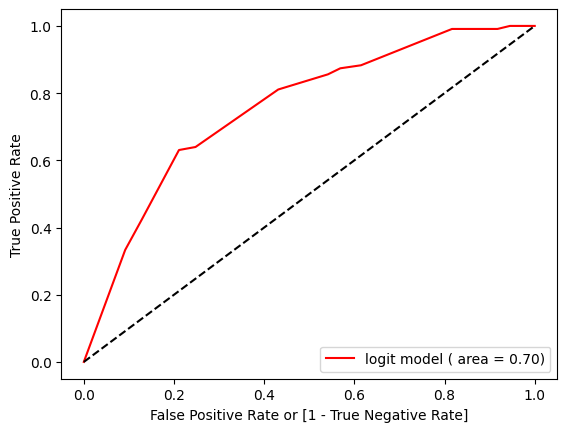

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, ada_boost.predict_proba(X_test)[:, 1]) # [:, 1] -> Fp and TP
auc=roc_auc_score(y_test,y_pred_test_adaboost)
print(auc)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red',label='logit model ( area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()


### Stacking

In [48]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()
knn = KNeighborsClassifier()
vc=VotingClassifier(estimators=[  ('lr',lr ), ('dt', dt), ('knn', knn)])
vc.fit(X_train,y_train)


,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [53]:
vc_pred_train=vc.predict(X_train)

In [54]:
accuracy_score(y_train,vc_pred_train)

0.819634703196347

In [55]:
vc_pred_test=vc.predict(X_test)

In [56]:
accuracy_score(y_test,vc_pred_test)

0.7136363636363636